<>:83: SyntaxWarning: invalid escape sequence '\o'
<>:83: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20080/1854361569.py:83: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Frequency $\omega$ (rad/s)")


Total Rows Loaded: 168000
Clean Rows (Good Fits): 167777
Dropped 223 bad fits.
Analyzing Detector: H1
Valid data points: 56000


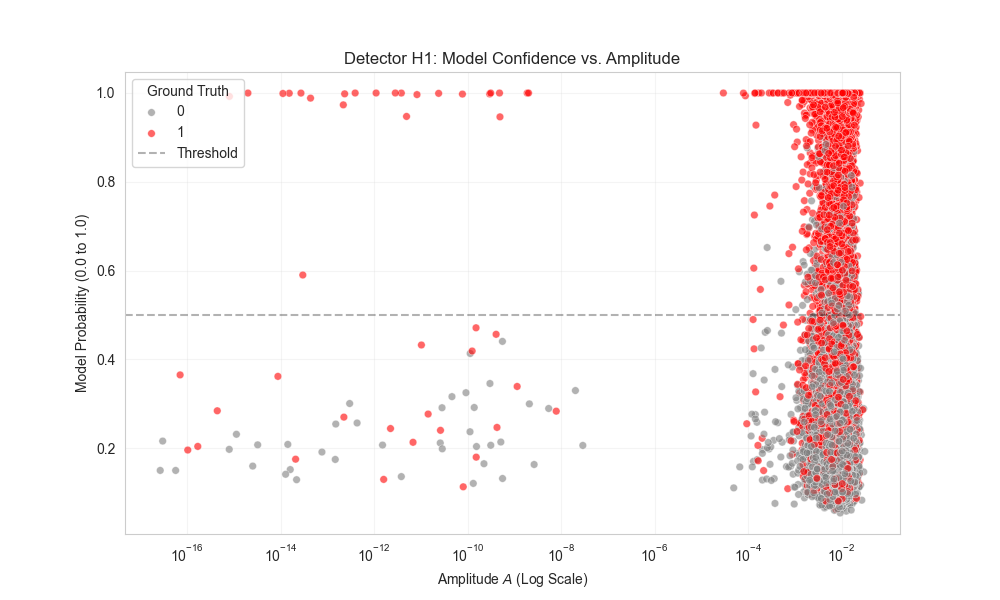

Text(0.5, 0, 'Frequency (Hz)')

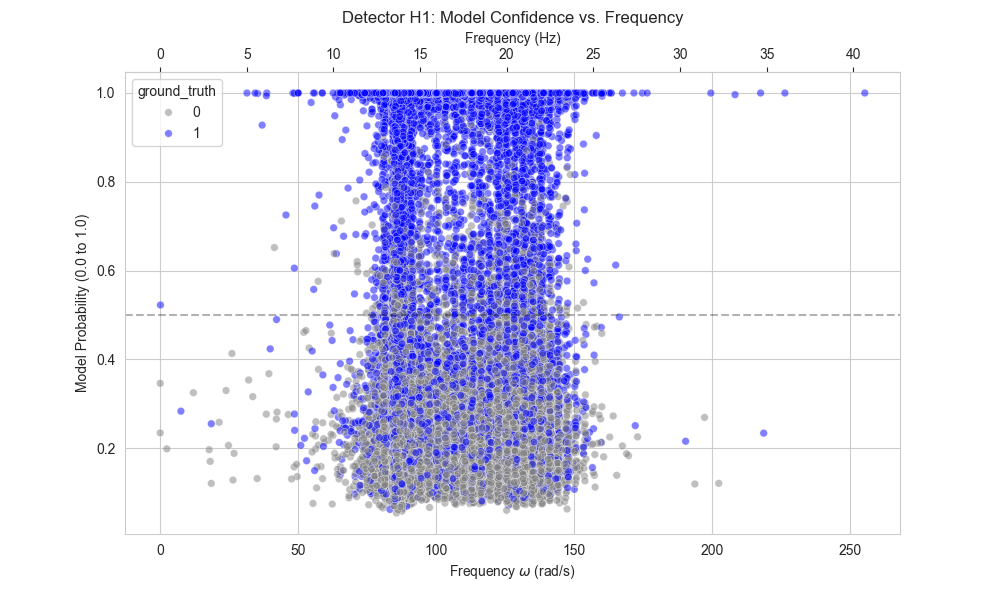

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the CSV
csv_path = "grav_wave_analysis_results.csv" # Use your actual filename
df = pd.read_csv(csv_path)

print(f"Total Rows Loaded: {len(df)}")

# 2. Filter: Keep only SUCCESSFUL fits
clean_df = df[
    (df['fit_success'] == True) & 
    (df['sigma_A'] < 100) & 
    (df['sigma_w'] < 1000)
].copy()

print(f"Clean Rows (Good Fits): {len(clean_df)}")
print(f"Dropped {len(df) - len(clean_df)} bad fits.")

# Preview the clean data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter: First Detector + Successful Fits
first_detector = df['detector'].unique()[0]

h1_df = df[
    (df['detector'] == first_detector) & 
    (df['fit_success'] == True) &
    (df['sigma_A'] < 100)  # Filter out garbage fits
].copy()

print(f"Analyzing Detector: {first_detector}")
print(f"Valid data points: {len(h1_df)}")

# ==========================================
# PLOT 1: Probability vs. Amplitude
# ==========================================
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=h1_df,
    x='A',
    y='model_prob',
    hue='ground_truth',
    palette={0: 'gray', 1: 'red'}, # Gray=Noise, Red=Wave
    alpha=0.6,
    s=30
)

plt.xscale('log')
plt.title(f"Detector {first_detector}: Model Confidence vs. Amplitude")
plt.xlabel("Amplitude $A$ (Log Scale)")
plt.ylabel("Model Probability (0.0 to 1.0)")
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3, label='Threshold')
plt.legend(title='Ground Truth')
plt.grid(True, which="both", alpha=0.2)
plt.show()

# ==========================================
# PLOT 2: Probability vs. Frequency
# ==========================================
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=h1_df,
    x='omega',
    y='model_prob',
    hue='ground_truth',
    palette={0: 'gray', 1: 'blue'},
    alpha=0.5,
    s=30
)

plt.title(f"Detector {first_detector}: Model Confidence vs. Frequency")
plt.xlabel("Frequency $\omega$ (rad/s)")
plt.ylabel("Model Probability (0.0 to 1.0)")
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)

secax = plt.gca().secondary_xaxis('top', functions=(lambda x: x / (2*np.pi), lambda x: x * (2*np.pi)))
secax.set_xlabel('Frequency (Hz)')

<>:60: SyntaxWarning: invalid escape sequence '\o'
<>:60: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20080/988807816.py:60: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("Frequency $\omega$ (rad/s)")


Analyzing Detector: H1 | Points: 56000


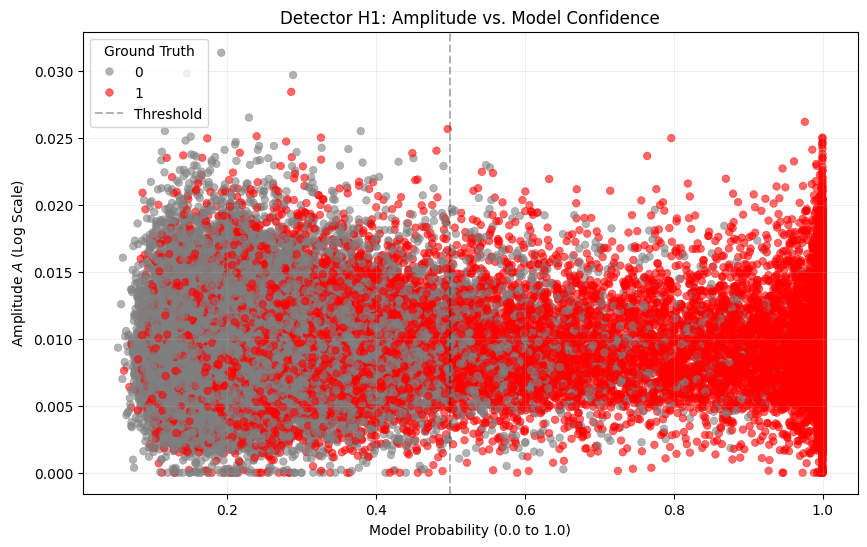

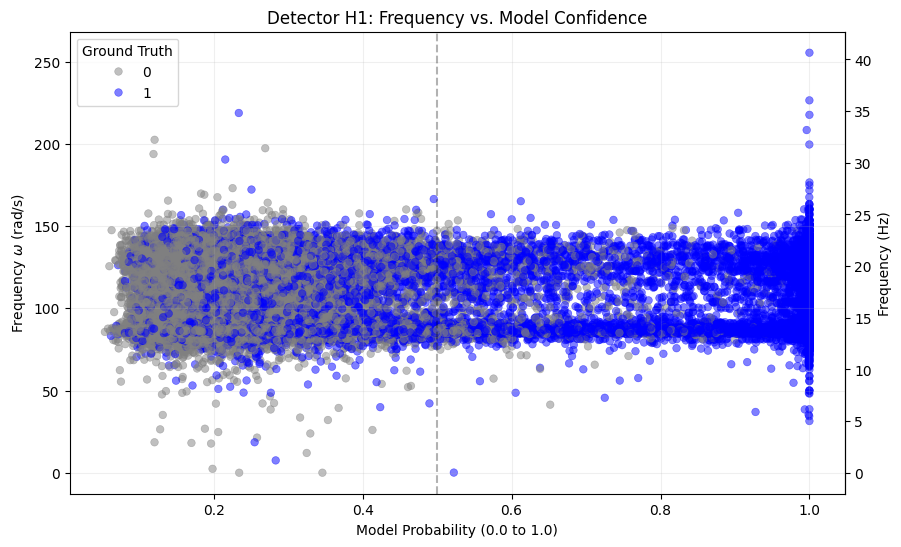

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter: First Detector + Successful Fits
first_detector = df['detector'].unique()[0]

h1_df = df[
    (df['detector'] == first_detector)
].copy()

print(f"Analyzing Detector: {first_detector} | Points: {len(h1_df)}")

# ==========================================
# PLOT 1: Amplitude vs. Probability
# ==========================================
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=h1_df,
    x='model_prob',  
    y='A',      
    hue='ground_truth',
    palette={0: 'gray', 1: 'red'},
    alpha=0.6,
    s=30,
    edgecolor=None
)

plt.title(f"Detector {first_detector}: Amplitude vs. Model Confidence")
plt.ylabel("Amplitude $A$ (Log Scale)")
plt.xlabel("Model Probability (0.0 to 1.0)")
plt.axvline(0.5, color='black', linestyle='--', alpha=0.3, label='Threshold') # Vertical line
plt.legend(title='Ground Truth', loc='upper left')
plt.grid(True, which="both", alpha=0.2)
plt.show()

# ==========================================
# PLOT 2: Frequency vs. Probability
# ==========================================
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=h1_df,
    x='model_prob',
    y='omega',   
    hue='ground_truth',
    palette={0: 'gray', 1: 'blue'},
    alpha=0.5,
    s=30,
    edgecolor=None
)

plt.title(f"Detector {first_detector}: Frequency vs. Model Confidence")
plt.ylabel("Frequency $\omega$ (rad/s)")
plt.xlabel("Model Probability (0.0 to 1.0)")
plt.axvline(0.5, color='black', linestyle='--', alpha=0.3)

secax = plt.gca().secondary_yaxis('right', functions=(lambda x: x / (2*np.pi), lambda x: x * (2*np.pi)))
secax.set_ylabel('Frequency (Hz)')

<>:16: SyntaxWarning: invalid escape sequence '\o'
<>:16: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20080/3838401000.py:16: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Frequency $\omega$ (rad/s)")


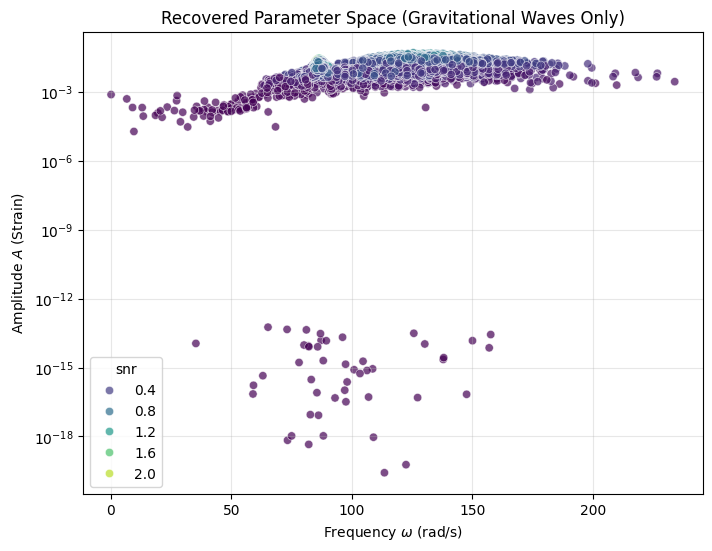

In [11]:
plt.figure(figsize=(8, 6))

# Filter for only CONFIRMED waves
waves = clean_df[clean_df['ground_truth'] == 1]

sns.scatterplot(
    data=waves, 
    x='omega', 
    y='A', 
    hue='snr', 
    palette='viridis', 
    alpha=0.7
)

plt.title("Recovered Parameter Space (Gravitational Waves Only)")
plt.xlabel("Frequency $\omega$ (rad/s)")
plt.ylabel("Amplitude $A$ (Strain)")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

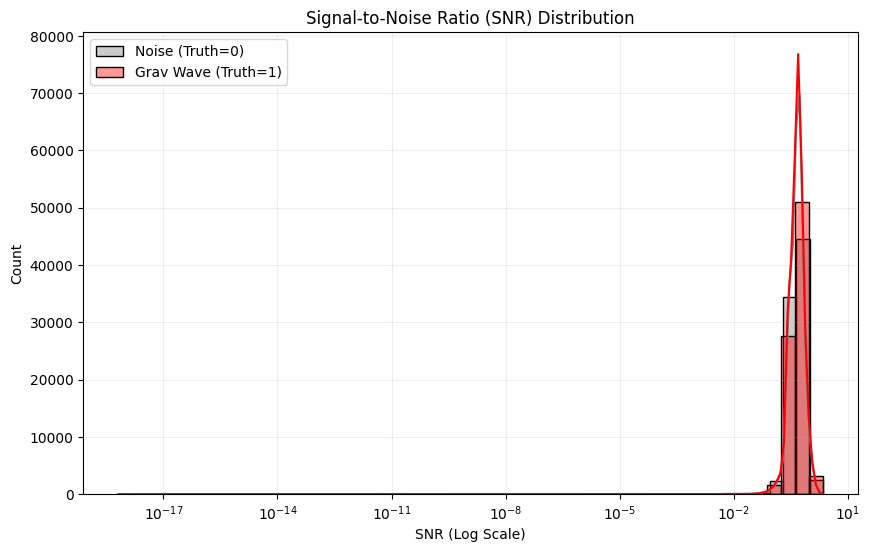

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=clean_df[clean_df['ground_truth'] == 0], 
    x='snr', 
    color='gray', 
    label='Noise (Truth=0)', 
    kde=True, 
    alpha=0.4,
    bins=50,
    log_scale=(True, False)
)

sns.histplot(
    data=clean_df[clean_df['ground_truth'] == 1], 
    x='snr', 
    color='red', 
    label='Grav Wave (Truth=1)', 
    kde=True, 
    alpha=0.4,
    bins=50,
    log_scale=(True, False)
)

plt.title("Signal-to-Noise Ratio (SNR) Distribution")
plt.xlabel("SNR (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

<>:75: SyntaxWarning: invalid escape sequence '\o'
<>:76: SyntaxWarning: invalid escape sequence '\o'
<>:101: SyntaxWarning: invalid escape sequence '\o'
<>:75: SyntaxWarning: invalid escape sequence '\o'
<>:76: SyntaxWarning: invalid escape sequence '\o'
<>:101: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20080/1394964909.py:75: SyntaxWarning: invalid escape sequence '\o'
  plt.title(f"Distribution of Normalized Frequency ($\omega$)\nDetector: {first_detector}")
/tmp/ipykernel_20080/1394964909.py:76: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Normalized Frequency $\omega$ (0=Low, 1=High)")
/tmp/ipykernel_20080/1394964909.py:101: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Normalized Frequency $\omega$")


Analyzing Detector: H1 | Valid Points: 55947


/tmp/ipykernel_20080/1394964909.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


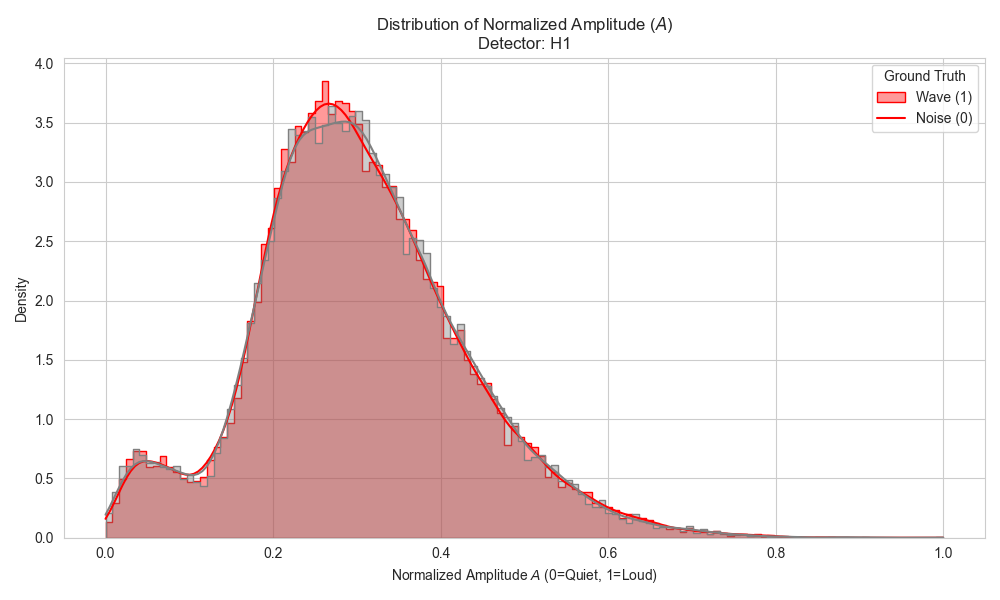

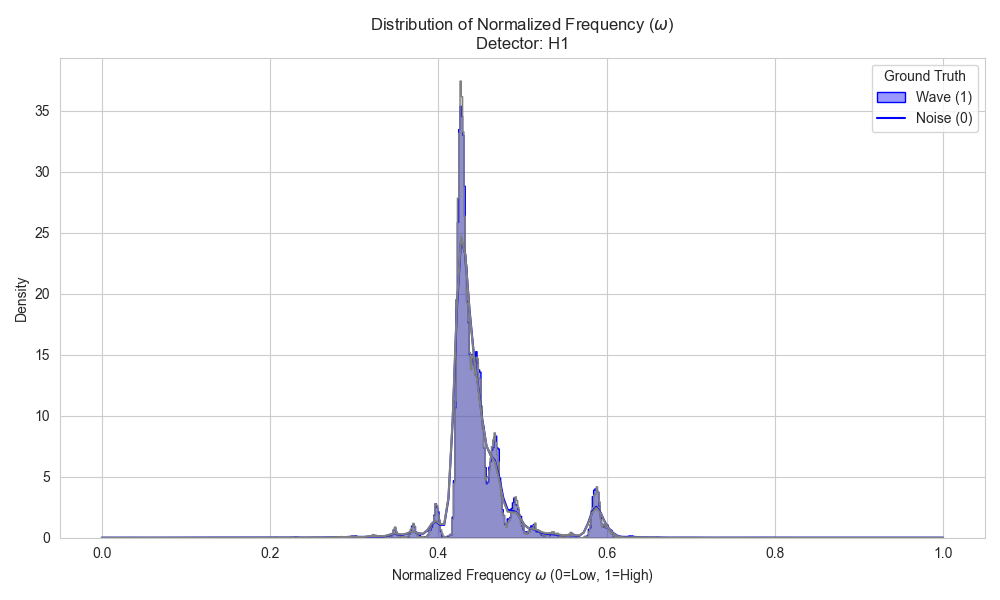

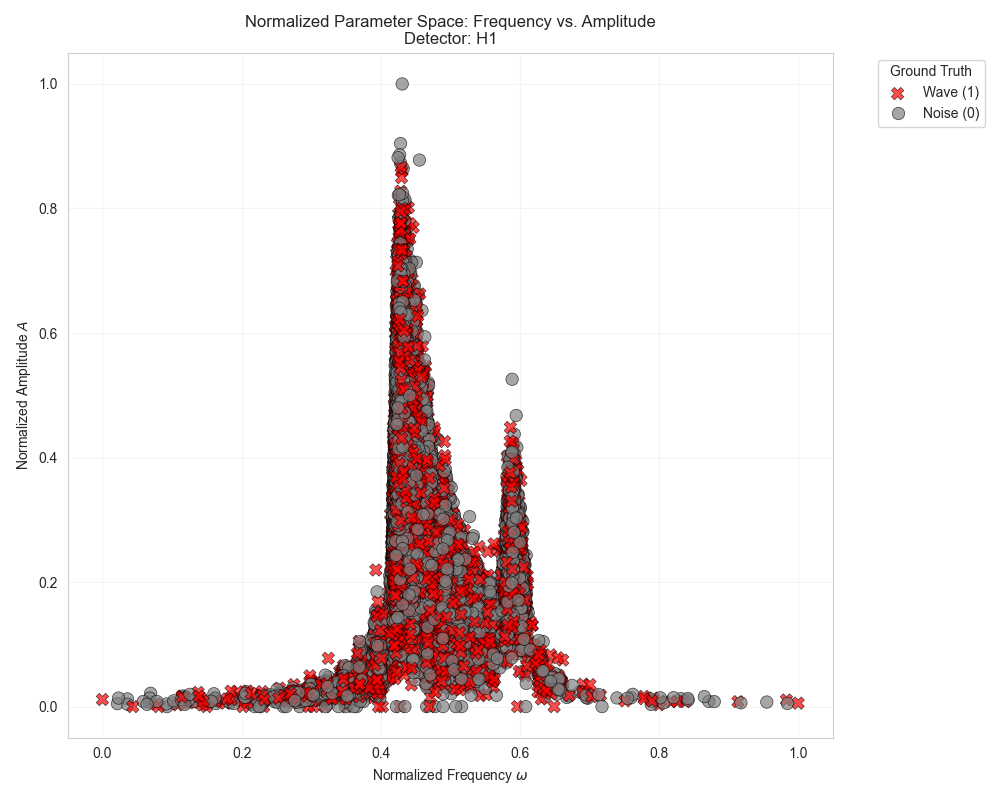

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter: First Detector + Successful Fits
first_detector = df['detector'].unique()[0]
plot_df = df[
    (df['detector'] == first_detector) & 
    (df['fit_success'] == True) &
    (df['sigma_A'] < 100) &
    (df['sigma_w'] < 1000)
].copy()

print(f"Analyzing Detector: {first_detector} | Valid Points: {len(plot_df)}")

# 3. Normalize A and Omega (0 to 1 Scale)
epsilon = 1e-9

a_min, a_max = plot_df['A'].min(), plot_df['A'].max()
plot_df['A_norm'] = (plot_df['A'] - a_min) / (a_max - a_min + epsilon)

w_min, w_max = plot_df['omega'].min(), plot_df['omega'].max()
plot_df['omega_norm'] = (plot_df['omega'] - w_min) / (w_max - w_min + epsilon)

sns.set_style("whitegrid")

# ==============================================================================
# PLOT 1: Normalized Amplitude Distribution
# ==============================================================================
plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_df,
    x='A_norm',
    hue='ground_truth',
    palette={0: 'gray', 1: 'red'},
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.4
)

plt.title(f"Distribution of Normalized Amplitude ($A$)\nDetector: {first_detector}")
plt.xlabel("Normalized Amplitude $A$ (0=Quiet, 1=Loud)")
plt.ylabel("Density")
plt.legend(title='Ground Truth', labels=['Wave (1)', 'Noise (0)'])
plt.tight_layout()
plt.show()

# ==============================================================================
# PLOT 2: Normalized Frequency Distribution
# ==============================================================================
plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_df,
    x='omega_norm',
    hue='ground_truth',
    palette={0: 'gray', 1: 'blue'},
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.4
)

plt.title(f"Distribution of Normalized Frequency ($\omega$)\nDetector: {first_detector}")
plt.xlabel("Normalized Frequency $\omega$ (0=Low, 1=High)")
plt.ylabel("Density")
plt.legend(title='Ground Truth', labels=['Wave (1)', 'Noise (0)'])
plt.tight_layout()
plt.show()

# ==============================================================================
# PLOT 3: Normalized Omega vs. Normalized Amplitude
# ==============================================================================
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=plot_df,
    x='omega_norm',
    y='A_norm',
    hue='ground_truth',
    style='ground_truth',
    palette={0: 'gray', 1: 'red'},
    s=80,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5
)

plt.title(f"Normalized Parameter Space: Frequency vs. Amplitude\nDetector: {first_detector}")
plt.xlabel("Normalized Frequency $\omega$")
plt.ylabel("Normalized Amplitude $A$")
plt.legend(title='Ground Truth', labels=['Wave (1)', 'Noise (0)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Max MSE: 0.00874586805989824
Min MSE: 0.0010083560863070496


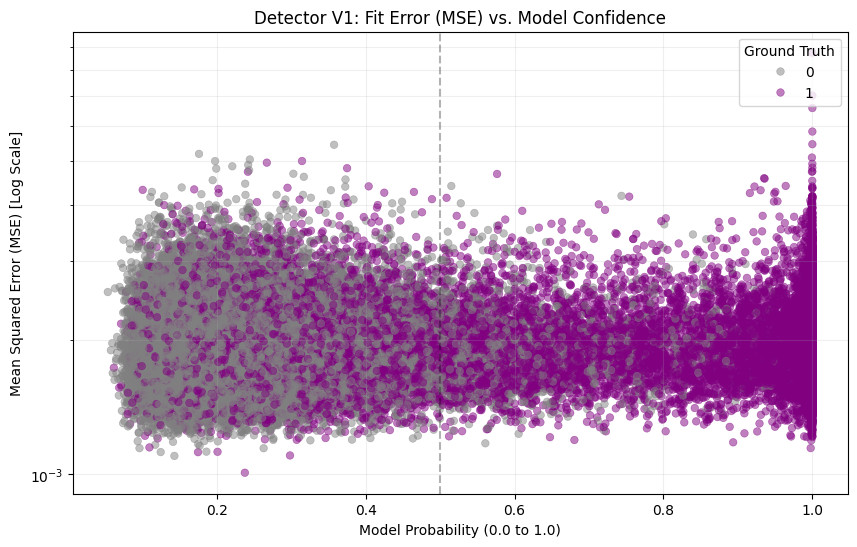

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter for Clean Fits
first_detector = df['detector'].unique()[2]
h1_df = df[
    (df['detector'] == first_detector) & 
    (df['fit_success'] == True) &
    (df['sigma_A'] < 100) 
].copy()

# ==========================================
# 3. CALCULATE MSE
# ==========================================
h1_df['mse'] = h1_df['rmse'] ** 2

print(f"Max MSE: {h1_df['mse'].max()}")
print(f"Min MSE: {h1_df['mse'].min()}")

# ==========================================
# 4. PLOT: MSE vs. Probability
# ==========================================
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=h1_df,
    x='model_prob',
    y='mse', 
    hue='ground_truth',
    palette={0: 'gray', 1: 'purple'},
    alpha=0.5,
    s=30,
    edgecolor=None
)

plt.yscale('log') 
plt.title(f"Detector {first_detector}: Fit Error (MSE) vs. Model Confidence")
plt.ylabel("Mean Squared Error (MSE) [Log Scale]")
plt.xlabel("Model Probability (0.0 to 1.0)")
plt.axvline(0.5, color='black', linestyle='--', alpha=0.3)
plt.legend(title='Ground Truth', loc='upper right')
plt.grid(True, which="both", alpha=0.2)
plt.show()

In [18]:
import pandas as pd

# 1. Load the Results
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Deduplicate to get Unique Events (Files)
events_df = df.drop_duplicates(subset=['file_id']).copy()

# ---------------------------------------------------------
# PART 1: OVERALL COUNTS
# ---------------------------------------------------------
total_events = len(events_df)
total_true = len(events_df[events_df['ground_truth'] == 1])
total_false = len(events_df[events_df['ground_truth'] == 0])

print(f"=== GLOBAL STATS ===")
print(f"Total Unique Files:   {total_events}")
print(f"Total Ground Truths:  {total_true} ({total_true/total_events*100:.1f}%)")
print(f"Total Ground Falses:  {total_false} ({total_false/total_events*100:.1f}%)")
print("\n")

# ---------------------------------------------------------
# PART 2: PROBABILITY BINNING
# ---------------------------------------------------------
bins = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0.0 - 0.2', '0.2 - 0.3', '0.3 - 0.4', '0.4 - 0.5', 
          '0.5 - 0.6', '0.6 - 0.7', '0.7 - 0.8', '0.8 - 0.9', '0.9 - 1.0']

# Apply binning
events_df['prob_bin'] = pd.cut(
    events_df['model_prob'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

# Calculate counts per bin
bin_stats = events_df.groupby('prob_bin', observed=False).agg(
    Total=('ground_truth', 'count'),
    True_Count=('ground_truth', 'sum')
)

bin_stats['False_Count'] = bin_stats['Total'] - bin_stats['True_Count']

# ---------------------------------------------------------
# PART 3: PRINT THE TABLE
# ---------------------------------------------------------
print(f"{'Prob Range':<12} | {'Total':<8} | {'Ground Truth (1)':<16} | {'Ground False (0)':<16}")
print("-" * 60)

for label in labels:
    if label in bin_stats.index:
        row = bin_stats.loc[label]
        print(f"{label:<12} | {row['Total']:<8} | {row['True_Count']:<16} | {row['False_Count']:<16}")
    else:
        print(f"{label:<12} | 0        | 0                | 0")

=== GLOBAL STATS ===
Total Unique Files:   56000
Total Ground Truths:  27948 (49.9%)
Total Ground Falses:  28052 (50.1%)


Prob Range   | Total    | Ground Truth (1) | Ground False (0)
------------------------------------------------------------
0.0 - 0.2    | 15531    | 3180             | 12351           
0.2 - 0.3    | 12949    | 3853             | 9096            
0.3 - 0.4    | 6160     | 2486             | 3674            
0.4 - 0.5    | 3096     | 1571             | 1525            
0.5 - 0.6    | 1862     | 1154             | 708             
0.6 - 0.7    | 1275     | 944              | 331             
0.7 - 0.8    | 1058     | 852              | 206             
0.8 - 0.9    | 1121     | 1002             | 119             
0.9 - 1.0    | 12948    | 12906            | 42              


Analyzing Detector: H1 | Valid Points: 55938


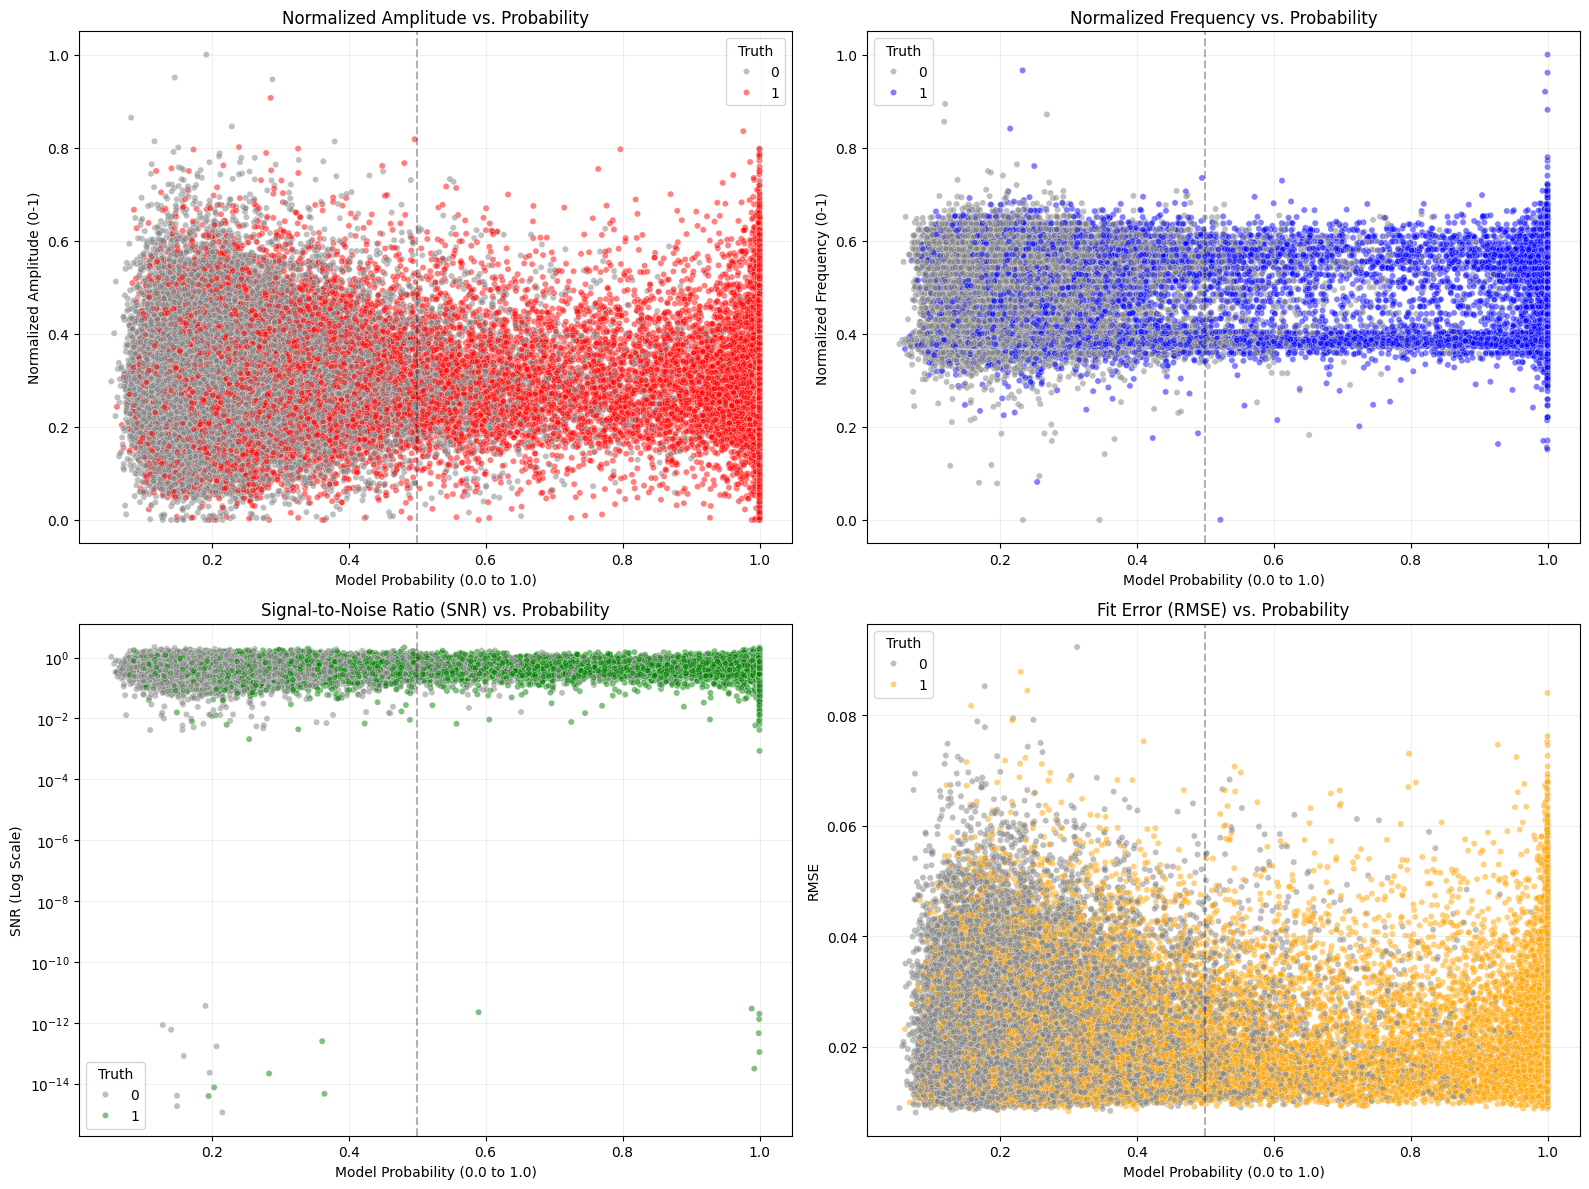

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter: First Detector + Successful Fits
first_detector = df['detector'].unique()[0]
plot_df = df[
    (df['detector'] == first_detector) & 
    (df['fit_success'] == True) &
    (df['sigma_A'] < 100) &
    (df['sigma_w'] < 1000)
].copy()

print(f"Analyzing Detector: {first_detector} | Valid Points: {len(plot_df)}")

# 3. Normalize A and Omega (0 to 1 Scale)
plot_df['A_norm'] = (plot_df['A'] - plot_df['A'].min()) / (plot_df['A'].max() - plot_df['A'].min())
plot_df['omega_norm'] = (plot_df['omega'] - plot_df['omega'].min()) / (plot_df['omega'].max() - plot_df['omega'].min())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Normalized Amplitude vs Prob ---
sns.scatterplot(
    data=plot_df, x='model_prob', y='A_norm',
    hue='ground_truth', palette={0: 'gray', 1: 'red'},
    alpha=0.5, s=20, ax=axes[0, 0]
)
axes[0, 0].set_title("Normalized Amplitude vs. Probability")
axes[0, 0].set_ylabel("Normalized Amplitude (0-1)")

# --- Plot 2: Normalized Frequency vs Prob ---
sns.scatterplot(
    data=plot_df, x='model_prob', y='omega_norm',
    hue='ground_truth', palette={0: 'gray', 1: 'blue'},
    alpha=0.5, s=20, ax=axes[0, 1]
)
axes[0, 1].set_title("Normalized Frequency vs. Probability")
axes[0, 1].set_ylabel("Normalized Frequency (0-1)")

# --- Plot 3: SNR vs Prob ---
sns.scatterplot(
    data=plot_df, x='model_prob', y='snr',
    hue='ground_truth', palette={0: 'gray', 1: 'green'},
    alpha=0.5, s=20, ax=axes[1, 0]
)
axes[1, 0].set_yscale('log') # SNR is best viewed in Log Scale
axes[1, 0].set_title("Signal-to-Noise Ratio (SNR) vs. Probability")
axes[1, 0].set_ylabel("SNR (Log Scale)")

# --- Plot 4: RMSE vs Prob ---
sns.scatterplot(
    data=plot_df, x='model_prob', y='rmse',
    hue='ground_truth', palette={0: 'gray', 1: 'orange'},
    alpha=0.5, s=20, ax=axes[1, 1]
)
axes[1, 1].set_title("Fit Error (RMSE) vs. Probability")
axes[1, 1].set_ylabel("RMSE")

for ax in axes.flatten():
    ax.set_xlabel("Model Probability (0.0 to 1.0)")
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.3) # Threshold line
    ax.grid(True, alpha=0.2)
    ax.legend(title='Truth', loc='upper left' if 'norm' in ax.get_ylabel() else 'best')

plt.tight_layout()
plt.show()

<>:62: SyntaxWarning: invalid escape sequence '\o'
<>:62: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20080/1778377461.py:62: SyntaxWarning: invalid escape sequence '\o'
  axes[1].set_title("Expected Normalized Frequency ($\omega$) vs. Probability (20 Bins)", fontsize=14)


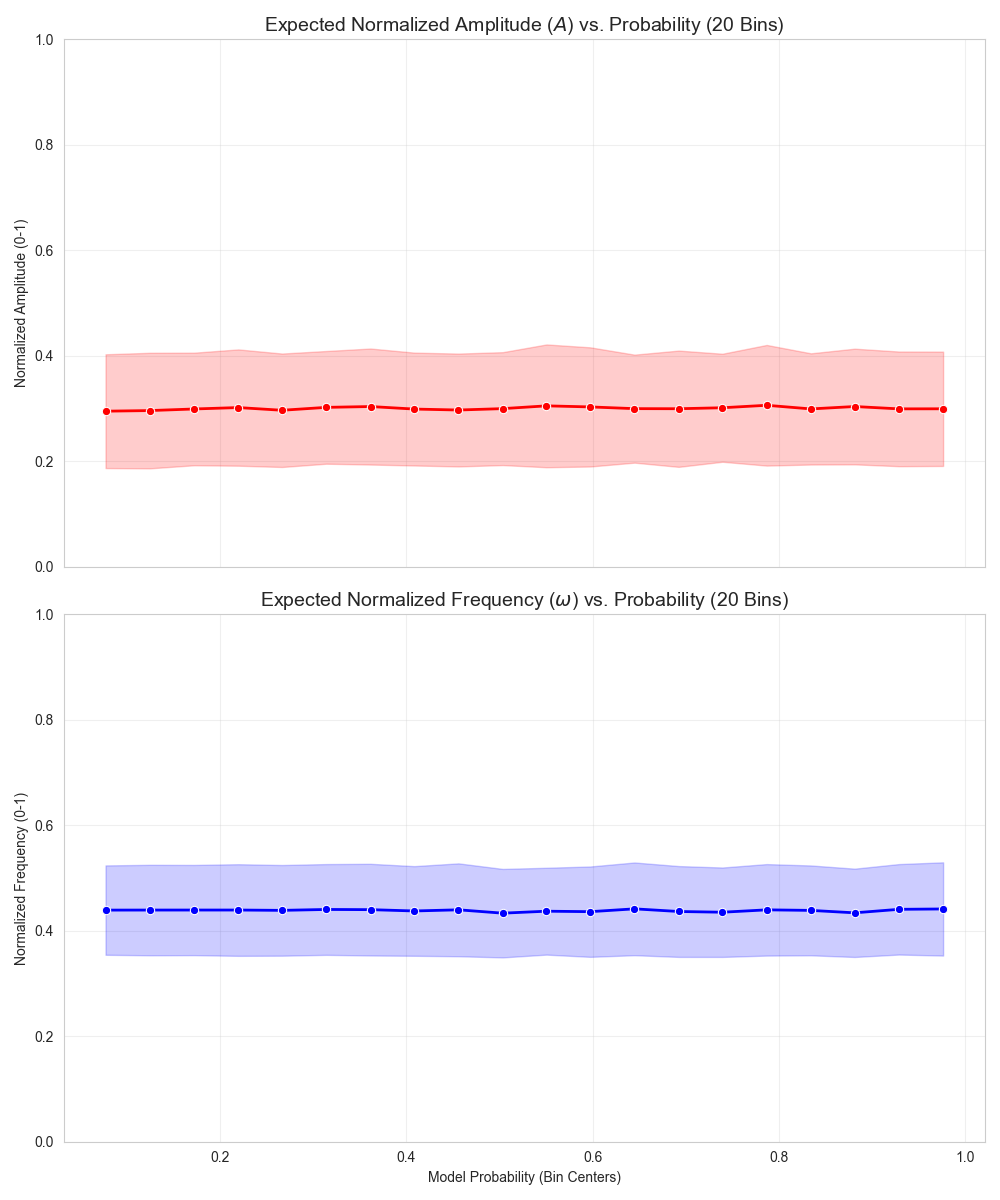

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter: First Detector + Successful Fits
first_detector = df['detector'].unique()[0]
plot_df = df[
    (df['detector'] == first_detector) & 
    (df['fit_success'] == True) &
    (df['sigma_A'] < 100) &
    (df['sigma_w'] < 1000)
].copy()

# 3. Normalize A and Omega (0 to 1 Scale)
epsilon = 1e-9
a_min, a_max = plot_df['A'].min(), plot_df['A'].max()
plot_df['A_norm'] = (plot_df['A'] - a_min) / (a_max - a_min + epsilon)

w_min, w_max = plot_df['omega'].min(), plot_df['omega'].max()
plot_df['omega_norm'] = (plot_df['omega'] - w_min) / (w_max - w_min + epsilon)

# 4. Bin Probabilities into 20 Bins
plot_df['prob_bin_interval'] = pd.cut(plot_df['model_prob'], bins=20)
plot_df['prob_bin_mid'] = plot_df['prob_bin_interval'].apply(lambda x: x.mid)

# 5. Plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# --- PLOT 1: Expected A vs Prob (20 Bins) ---
sns.lineplot(
    data=plot_df, 
    x='prob_bin_mid', 
    y='A_norm', 
    errorbar='sd', 
    color='red', 
    marker='o',
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title("Expected Normalized Amplitude ($A$) vs. Probability (20 Bins)", fontsize=14)
axes[0].set_ylabel("Normalized Amplitude (0-1)")
axes[0].set_ylim(0, 1)  # Fixed Y-Axis
axes[0].grid(True, alpha=0.3)

# --- PLOT 2: Expected Omega vs Prob (20 Bins) ---
sns.lineplot(
    data=plot_df, 
    x='prob_bin_mid', 
    y='omega_norm', 
    errorbar='sd', 
    color='blue', 
    marker='o',
    linewidth=2,
    ax=axes[1]
)
axes[1].set_title("Expected Normalized Frequency ($\omega$) vs. Probability (20 Bins)", fontsize=14)
axes[1].set_ylabel("Normalized Frequency (0-1)")
axes[1].set_xlabel("Model Probability (Bin Centers)")
axes[1].set_ylim(0, 1)  # Fixed Y-Axis
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<>:59: SyntaxWarning: invalid escape sequence '\o'
<>:59: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20080/1311660797.py:59: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Normalized Frequency ($\omega$)")


Clustering Data for Detector: H1 | Points: 55938


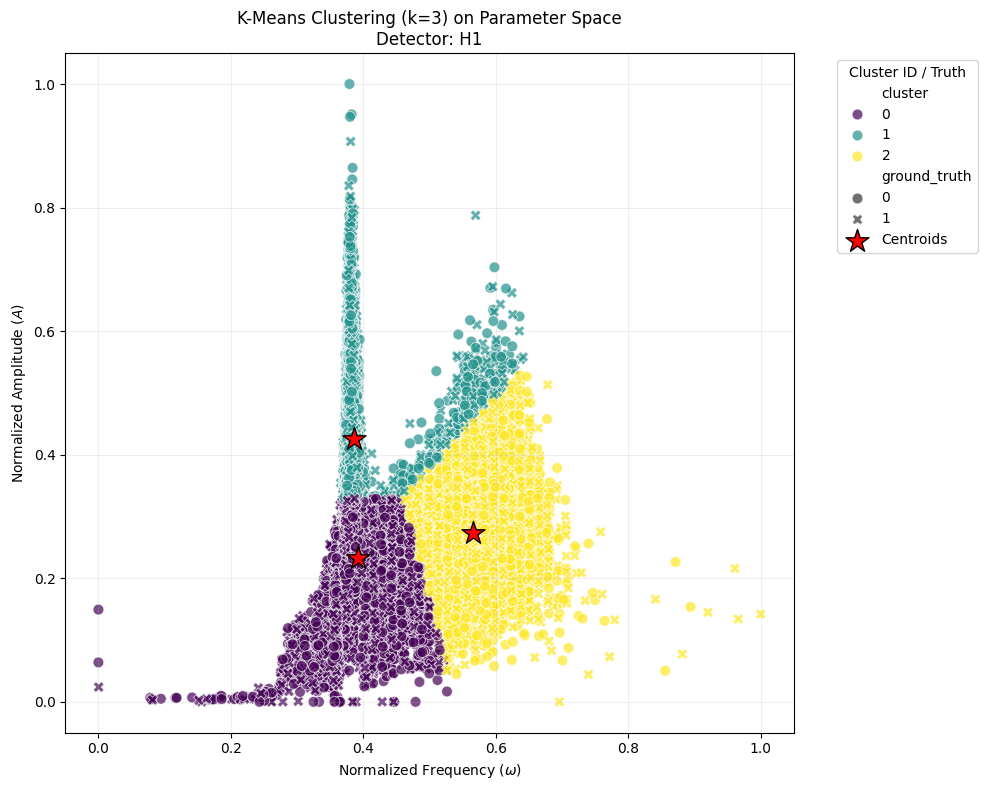

Cluster Centers (A_norm, omega_norm):
[[0.23298631 0.39223413]
 [0.42531995 0.38541361]
 [0.27336258 0.56566369]]


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter: First Detector + Successful Fits
first_detector = df['detector'].unique()[0]

cluster_df = df[
    (df['detector'] == first_detector) & 
    (df['fit_success'] == True) &
    (df['sigma_A'] < 100) &
    (df['sigma_w'] < 1000)
].copy()

print(f"Clustering Data for Detector: {first_detector} | Points: {len(cluster_df)}")

# 3. Normalize A and Omega (Min-Max Scaling 0-1)
cluster_df['A_norm'] = (cluster_df['A'] - cluster_df['A'].min()) / (cluster_df['A'].max() - cluster_df['A'].min())
cluster_df['omega_norm'] = (cluster_df['omega'] - cluster_df['omega'].min()) / (cluster_df['omega'].max() - cluster_df['omega'].min())

# 4. Run K-Means
X = cluster_df[['A_norm', 'omega_norm']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_df['cluster'] = kmeans.fit_predict(X)

# 5. Plot Results
plt.figure(figsize=(10, 8))

# Scatter Plot
sns.scatterplot(
    data=cluster_df,
    x='omega_norm',
    y='A_norm',
    hue='cluster',
    style='ground_truth',
    palette='viridis',
    s=60,
    alpha=0.7
)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 0], c='red', s=300, marker='*', label='Centroids', edgecolor='black')

plt.title(f"K-Means Clustering (k=3) on Parameter Space\nDetector: {first_detector}")
plt.xlabel("Normalized Frequency ($\omega$)")
plt.ylabel("Normalized Amplitude ($A$)")
plt.legend(title='Cluster ID / Truth', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Cluster Centers (A_norm, omega_norm):")
print(centers)

<>:59: SyntaxWarning: invalid escape sequence '\o'
<>:59: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20080/2426547747.py:59: SyntaxWarning: invalid escape sequence '\o'
  axes[1].set_xlabel("Normalized Frequency $\omega$", fontsize=12)


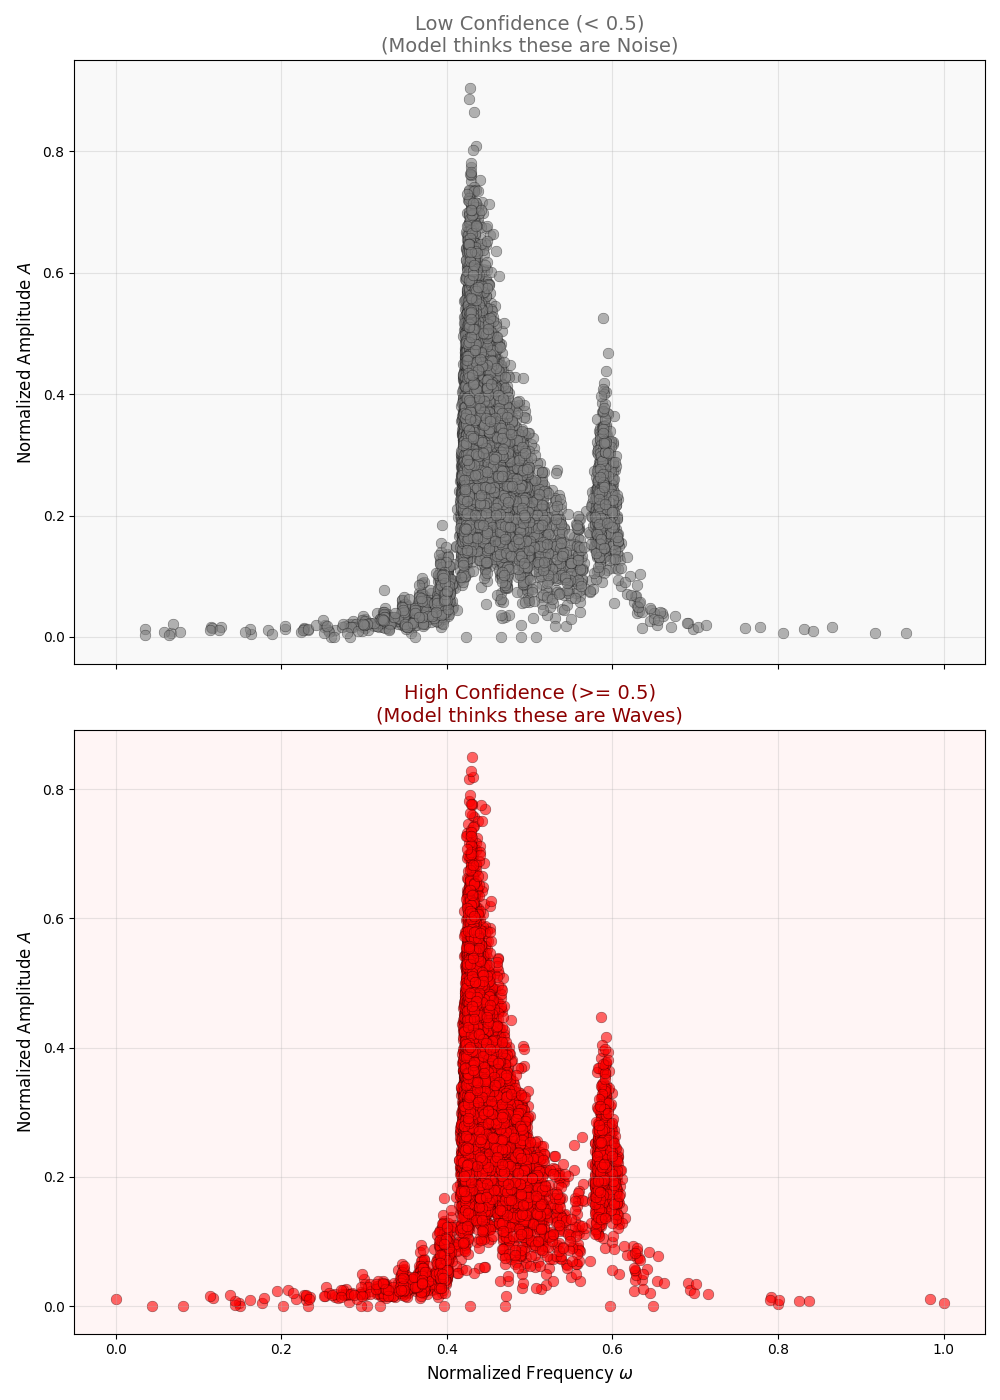

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter: First Detector + Successful Fits
first_detector = df['detector'].unique()[0]
plot_df = df[
    (df['detector'] == first_detector) & 
    (df['fit_success'] == True) &
    (df['sigma_A'] < 100) &
    (df['sigma_w'] < 1000)
].copy()

# 3. Normalize A and Omega (0 to 1 Scale)
plot_df['A_norm'] = (plot_df['A'] - plot_df['A'].min()) / (plot_df['A'].max() - plot_df['A'].min())
plot_df['omega_norm'] = (plot_df['omega'] - plot_df['omega'].min()) / (plot_df['omega'].max() - plot_df['omega'].min())

# 4. Split Data
low_prob_df = plot_df[plot_df['model_prob'] < 0.2]
high_prob_df = plot_df[plot_df['model_prob'] >= 0.9]

# 5. Create Vertical Plots (2 Rows, 1 Column)
# figsize=(Width, Height) - Increased height for vertical stacking
fig, axes = plt.subplots(2, 1, figsize=(10, 14), sharex=True)

# --- PLOT 1: Low Probability (< 0.5) ---
sns.scatterplot(
    data=low_prob_df,
    x='omega_norm',
    y='A_norm',
    color='gray',           # Single color, no Ground Truth distinction
    s=60,
    alpha=0.6,
    edgecolor='k',
    linewidth=0.3,
    ax=axes[0]
)
axes[0].set_title(f"Low Confidence (< 0.5)\n(Model thinks these are Noise)", fontsize=14, color='dimgray')
axes[0].set_ylabel("Normalized Amplitude $A$", fontsize=12)
axes[0].set_facecolor('#f9f9f9') 

# --- PLOT 2: High Probability (>= 0.5) ---
sns.scatterplot(
    data=high_prob_df,
    x='omega_norm',
    y='A_norm',
    color='red',            # Single color, no Ground Truth distinction
    s=60,
    alpha=0.6,
    edgecolor='k',
    linewidth=0.3,
    ax=axes[1]
)
axes[1].set_title(f"High Confidence (>= 0.5)\n(Model thinks these are Waves)", fontsize=14, color='darkred')
axes[1].set_xlabel("Normalized Frequency $\omega$", fontsize=12)
axes[1].set_ylabel("Normalized Amplitude $A$", fontsize=12)
axes[1].set_facecolor('#fff5f5')

# Grid and Final Adjustments
for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<>:55: SyntaxWarning: invalid escape sequence '\o'
<>:55: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20080/2973798315.py:55: SyntaxWarning: invalid escape sequence '\o'
  axes[1].set_title("Normalized Frequency ($\omega$) vs. Model Probability", fontsize=14)


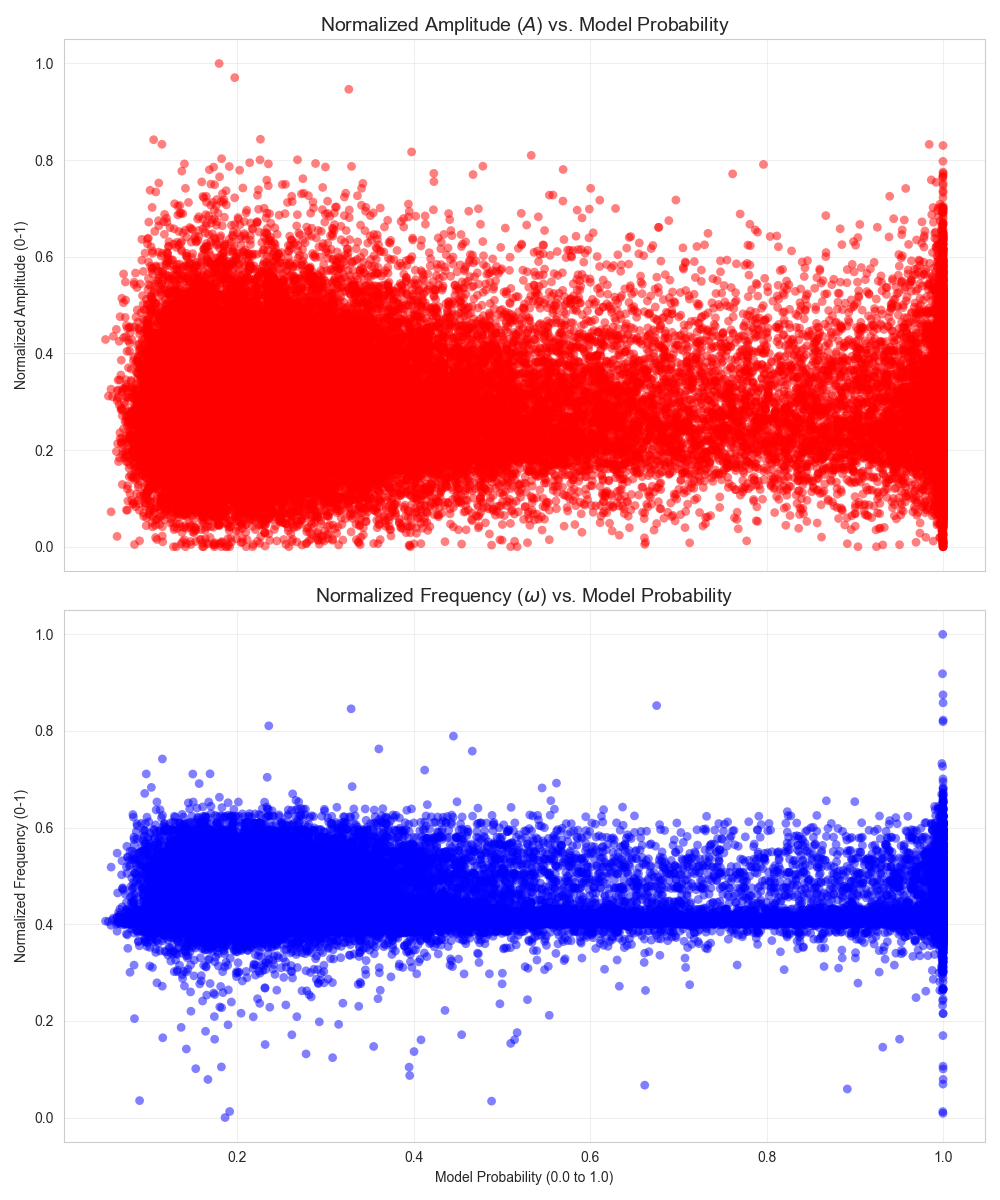

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter: First Detector + Successful Fits
first_detector = df['detector'].unique()[0]
plot_df = df[
    (df['detector'] == first_detector) & 
    (df['fit_success'] == True) &
    (df['sigma_A'] < 100) &
    (df['sigma_w'] < 1000)
].copy()

# 3. Normalize A and Omega (0 to 1 Scale)
epsilon = 1e-9
a_min, a_max = plot_df['A'].min(), plot_df['A'].max()
plot_df['A_norm'] = (plot_df['A'] - a_min) / (a_max - a_min + epsilon)

w_min, w_max = plot_df['omega'].min(), plot_df['omega'].max()
plot_df['omega_norm'] = (plot_df['omega'] - w_min) / (w_max - w_min + epsilon)

# 4. Plotting (Vertical Layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# --- PLOT 1: Normalized A vs Prob ---
sns.scatterplot(
    data=plot_df, 
    x='model_prob', 
    y='A_norm', 
    color='red',       # Single color (Monochrome)
    s=40,                # Dot size
    alpha=0.5,           # Transparency
    edgecolor='none',
    ax=axes[0]
)
axes[0].set_title("Normalized Amplitude ($A$) vs. Model Probability", fontsize=14)
axes[0].set_ylabel("Normalized Amplitude (0-1)")
axes[0].grid(True, alpha=0.3)

# --- PLOT 2: Normalized Omega vs Prob ---
sns.scatterplot(
    data=plot_df, 
    x='model_prob', 
    y='omega_norm', 
    color='blue',       # Single color
    s=40,
    alpha=0.5,
    edgecolor='none',
    ax=axes[1]
)
axes[1].set_title("Normalized Frequency ($\omega$) vs. Model Probability", fontsize=14)
axes[1].set_ylabel("Normalized Frequency (0-1)")
axes[1].set_xlabel("Model Probability (0.0 to 1.0)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

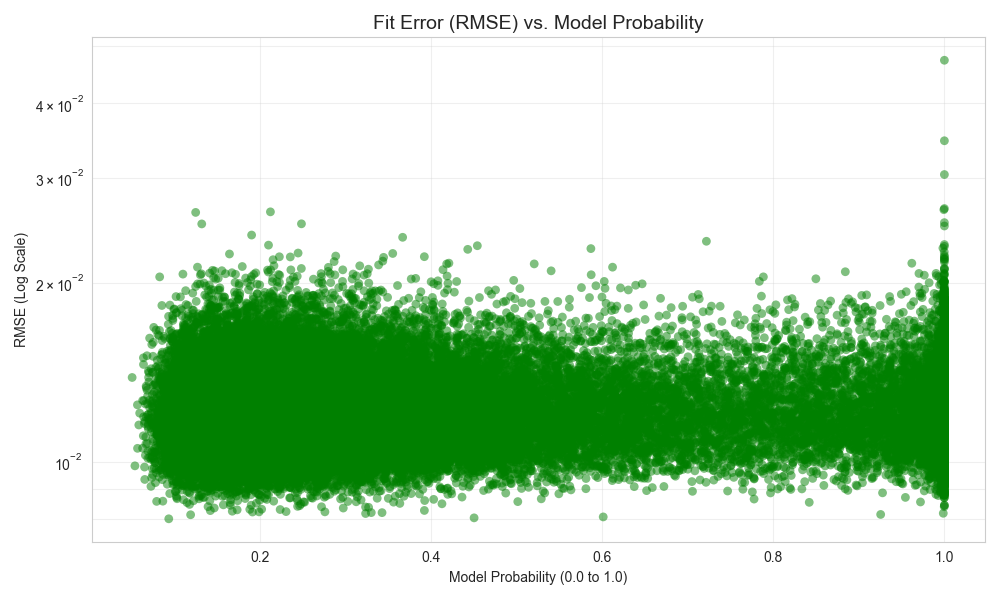

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv("grav_wave_analysis_results.csv")

# 2. Filter
first_detector = df['detector'].unique()[0]
plot_df = df[
    (df['detector'] == first_detector) & 
    (df['fit_success'] == True) &
    (df['sigma_A'] < 100) &
    (df['sigma_w'] < 1000)
].copy()

# 3. Plotting
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df, 
    x='model_prob', 
    y='rmse',       # Assumes 'rmse' column exists from your fitting step
    color='green',  # Single color
    s=40,
    alpha=0.5,
    edgecolor='none'
)

plt.title(f"Fit Error (RMSE) vs. Model Probability", fontsize=14)
plt.xlabel("Model Probability (0.0 to 1.0)")
plt.ylabel("RMSE (Log Scale)")
plt.yscale('log')   # Errors usually span many orders of magnitude
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

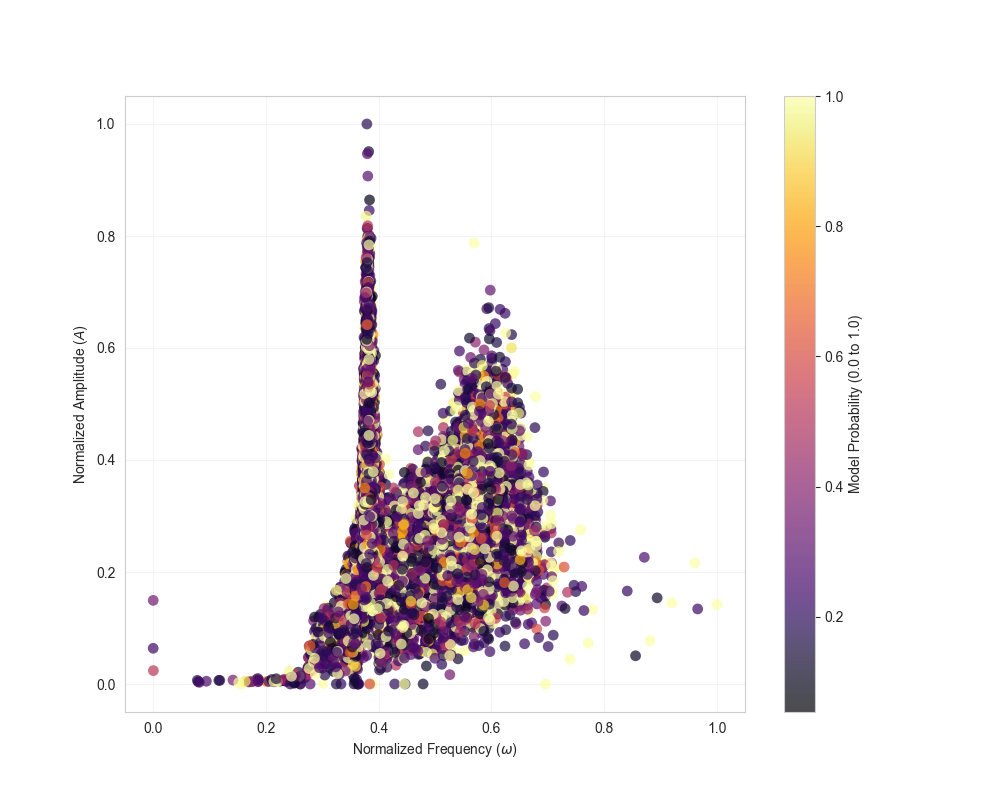

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Scatter plot where Color = Probability
points = plt.scatter(
    plot_df['omega_norm'], 
    plot_df['A_norm'], 
    c=plot_df['model_prob'],  # Color acts as the 3rd dimension
    cmap='inferno',           # Dark=Low Prob, Bright Yellow=High Prob
    s=60,                     # Constant size
    alpha=0.7,
    edgecolor='none'
)

plt.xlabel(r'Normalized Frequency ($\omega$)')
plt.ylabel(r'Normalized Amplitude ($A$)')
#plt.title(f'Detection Confidence Map\n(Color = Model Probability)')

# Add Colorbar
cbar = plt.colorbar(points)
cbar.set_label('Model Probability (0.0 to 1.0)')

plt.grid(True, alpha=0.2)
plt.show()